In [2]:
!pip install -q fastparquet
!pip install -q statsforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 47.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 3.3 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsforecast import StatsForecast
from statsforecast.models import TSB, AutoETS, AutoARIMA, Naive, SeasonalNaive, Theta, OptimizedTheta, CrostonOptimized, ADIDA, IMAPA, CrostonSBA, HoltWinters

In [4]:
# данные о реальном спросе
real_demand = pd.read_parquet('/kaggle/input/datasets/faibus/diploma/real_demand_data.parquet', engine='fastparquet')

# выгружаем типы рядов
ts_dict_df = pd.read_csv('/kaggle/input/datasets/faibus/diploma/ts_dict_df')[['SKU_id', 'ts_type']]

In [5]:
# Выделяем SKU, принадлежащие к типу lumpy
lumpy_ts = list(ts_dict_df.query(" ts_type == 'smooth' ")['SKU_id'])

# фильтруем датасет по lumpy_ts
real_demand = real_demand.query(" SKU_id.isin(@lumpy_ts) ")

# причесываем датасет
real_demand = real_demand.rename(columns = {'date':'ds', 'real_demand':'y', 'SKU_id':'unique_id'})[['unique_id', 'ds', 'y']]

real_demand

,unique_id,ds,y
0,140322960,2024-01-01,1.0
1,140322962,2024-01-01,1.0
2,140322966,2024-01-01,1.0
3,140322970,2024-01-01,1.0
4,140322973,2024-01-01,1.0
...,...,...,...
5266172,140322981,2025-09-30,144.0
5266173,142954372,2025-09-30,156.0
5266174,142954358,2025-09-30,161.0
5266175,1746835558,2025-09-30,170.0


In [12]:
# 1. Создаем список с моделями
models = [
    SeasonalNaive(season_length=7, alias='SeasonalNaive7'),
    Naive(alias='Naive'),
    AutoETS(alias='AutoETS'),
    AutoARIMA(alias='AutoARIMA'),
    OptimizedTheta(alias='OptTheta'),
    HoltWinters(season_length=7, error_type="A", alias='HoltWinters_add_w_seas'),
    ADIDA(alias='ADIDA'),
    IMAPA(alias='IMAPA')
]

# TSB - эталон для lumpy рядов
# ETS - семейство экспоненциальных сглаживаний
# SeasonalNaive - примитивный лаговый прогноз
# Naive - прогноз это последнее значение ряда
# Theta - разбивает ряд на компоненты (линии ряда), каждая компонента прогнозируется отдельно, потом прогнозы комбинируются для получения результата
# ARIMA - семейство ARIMA моделей

In [13]:
# задаем параметры
horizon = 14
step_size = 7
n_windows = 5

# определяем минимально необходимую длину ряда
min_required = n_windows * step_size + horizon

# Группировка и подсчёт длины
series_len = real_demand.groupby('unique_id').size()
long_series = series_len[series_len >= min_required].index

# Оставляем только длинные ряды
real_demand_filtered = real_demand[real_demand['unique_id'].isin(long_series)]

# Создаём экземпляр StatsForecast со списком моделей
sf = StatsForecast(models=models, freq='D', n_jobs=1, fallback_model=Naive())

# Теперь запускаем кросс-валидацию на отфильтрованных данных
cv_results = sf.cross_validation(
    df=real_demand_filtered,
    h=horizon,
    step_size=step_size,
    n_windows=n_windows
)

/usr/local/lib/python3.12/dist-packages/statsforecast/ets.py:653: RuntimeWarning: divide by zero encountered in scalar divide
  sigma2 = np.sum(e**2) / (ny - np_ - 1)
/usr/local/lib/python3.12/dist-packages/statsforecast/ets.py:653: RuntimeWarning: divide by zero encountered in scalar divide
  sigma2 = np.sum(e**2) / (ny - np_ - 1)
/usr/local/lib/python3.12/dist-packages/statsforecast/ets.py:653: RuntimeWarning: divide by zero encountered in scalar divide
  sigma2 = np.sum(e**2) / (ny - np_ - 1)
/usr/local/lib/python3.12/dist-packages/statsforecast/ets.py:653: RuntimeWarning: divide by zero encountered in scalar divide
  sigma2 = np.sum(e**2) / (ny - np_ - 1)
/usr/local/lib/python3.12/dist-packages/statsforecast/ets.py:653: RuntimeWarning: divide by zero encountered in scalar divide
  sigma2 = np.sum(e**2) / (ny - np_ - 1)
/usr/local/lib/python3.12/dist-packages/statsforecast/ets.py:653: RuntimeWarning: divide by zero encountered in scalar divide
  sigma2 = np.sum(e**2) / (ny - np_ - 1

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -------------------------------
# 1. Определение метрик
# -------------------------------

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype='float64')
    y_pred = np.asarray(y_pred, dtype='float64')
    denominator = np.abs(y_true) + np.abs(y_pred)
    mask = denominator > 0
    if mask.sum() == 0:
        return np.nan
    return (2 * np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]).mean() * 100

def wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype='float64')
    y_pred = np.asarray(y_pred, dtype='float64')
    denominator = np.abs(y_true).sum()
    if denominator == 0:
        return np.nan
    return np.abs(y_true - y_pred).sum() / denominator * 100

# -------------------------------
# 2. Функция для вычисления метрик по каждому окну (без unique_id)
# -------------------------------

def compute_metrics_per_window(cv_results, model_columns, metrics_dict):
    """
    cv_results: DataFrame от sf.cross_validation()
    model_columns: список имён столбцов с прогнозами моделей
    metrics_dict: словарь вида {'mae': mae, 'rmse': rmse, ...}
    Возвращает DataFrame с колонками: cutoff, model, и каждой метрикой.
    Для каждого cutoff (окна) метрика вычисляется по всем точкам всех unique_id.
    """
    records = []
    grouped = cv_results.groupby('cutoff')   # группируем только по окну
    
    for cutoff, group in grouped:
        y_true = group['y'].values
        for model in model_columns:
            y_pred = group[model].values
            row = {'cutoff': cutoff, 'model': model}
            for metric_name, metric_func in metrics_dict.items():
                row[metric_name] = metric_func(y_true, y_pred)
            records.append(row)
    
    return pd.DataFrame(records)

# -------------------------------
# 3. Применение к вашим данным
# -------------------------------

# Предполагаем, что cv_results уже получен после cross_validation
# Определяем столбцы моделей (все, кроме служебных)
model_columns = [col for col in cv_results.columns 
                 if col not in ['unique_id', 'ds', 'cutoff', 'y']]

metrics = {
    'mae': mae,
    'rmse': rmse,
    'smape': smape,
    'wape': wape
}

# Вычисляем метрики для каждого окна (без разбивки по unique_id)
metrics_per_window = compute_metrics_per_window(cv_results, model_columns, metrics)

# -------------------------------
# 4. Агрегация результатов
# -------------------------------

# 4.1. Среднее по всем окнам для каждой модели
summary_mean = metrics_per_window.groupby('model')[['mae', 'rmse', 'smape', 'wape']].mean()


# 4.2. Детальная статистика (mean, std, min, max) по окнам
summary_stats = metrics_per_window.groupby('model')[['mae', 'rmse', 'smape', 'wape']].agg(['mean', 'std', 'min', 'max'])


summary_mean

,mae,rmse,smape,wape
model,,,,
ADIDA,3.018203,4.128746,55.850780,47.416860
AutoARIMA,3.165120,4.296187,56.718646,50.055526
AutoETS,3.199497,4.359823,57.622106,50.157480
HoltWinters_add_w_seas,3.345834,4.519396,59.731080,52.640116
IMAPA,3.018609,4.129826,55.805189,47.429556
Naive,3.728044,5.001519,70.232455,56.810330
OptTheta,3.241521,4.406293,57.931757,50.724461
SeasonalNaive7,3.861087,5.308840,71.076570,60.096411


In [23]:
real_demand.query("y == 0").tail(50)

,unique_id,ds,y
5258577,983082053,2025-09-30,0.0
5258603,994045179,2025-09-30,0.0
5258929,1122736386,2025-09-30,0.0
5259007,1173553934,2025-09-30,0.0
5259277,1252731144,2025-09-30,0.0
5260080,1525456644,2025-09-30,0.0
5260207,1564823868,2025-09-30,0.0
5260267,1574138912,2025-09-30,0.0
5260274,1574139213,2025-09-30,0.0
5260289,1574139927,2025-09-30,0.0


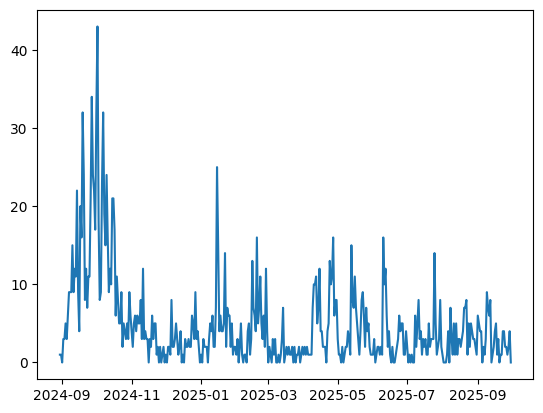

In [62]:
i = 1665092945
y = list(real_demand.query(" unique_id == @i")['y'])
x = list(real_demand.query(" unique_id == @i")['ds'])

plt.plot(x,y)

In [55]:
real_demand.query("unique_id == @i").tail(50)

,unique_id,ds,y
4777091,1791208618,2025-08-12,15.0
4787168,1791208618,2025-08-13,15.0
4796416,1791208618,2025-08-14,5.0
4806927,1791208618,2025-08-15,9.0
4817435,1791208618,2025-08-16,21.0
4827473,1791208618,2025-08-17,21.0
4837443,1791208618,2025-08-18,20.0
4847587,1791208618,2025-08-19,28.0
4857483,1791208618,2025-08-20,19.0
4866936,1791208618,2025-08-21,7.0


In [48]:
# данные о стоках
stock = pd.read_parquet('/kaggle/input/datasets/faibus/diploma/stock_data.parquet', engine='fastparquet')

,DATE,SKU_id,stock_qty
0,2024-01-01,140183675,116
1,2024-01-01,140183676,418
2,2024-01-01,140183682,92
3,2024-01-01,140183690,290
4,2024-01-01,140183698,14
...,...,...,...
8517043,2025-09-30,2824998317,348
8517044,2025-09-30,2839247926,32
8517045,2025-09-30,2847550636,1
8517046,2025-09-30,2850435492,1205


In [56]:
stock.query("SKU_id == @i").tail(50)

,DATE,SKU_id,stock_qty
7594573,2025-07-23,1791208618,15
7608628,2025-07-24,1791208618,12
7622509,2025-07-25,1791208618,11
7636408,2025-07-26,1791208618,11
7650225,2025-07-27,1791208618,16
7664081,2025-07-28,1791208618,13
7677980,2025-07-29,1791208618,52
7691892,2025-07-30,1791208618,42
7705806,2025-07-31,1791208618,82
7719715,2025-08-01,1791208618,116
